In [79]:
import os
import sys

PROJECT_NAME = 'june-2026'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Practice\PnT\june-2026


In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [81]:
df = pd.read_csv("./datasets/diabetes.csv")
df.shape

(768, 9)

In [82]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [83]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [84]:
df.columns.to_list()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [85]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [87]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [88]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [89]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [90]:
df.min()

Pregnancies                  0.000
Glucose                      0.000
BloodPressure                0.000
SkinThickness                0.000
Insulin                      0.000
BMI                          0.000
DiabetesPedigreeFunction     0.078
Age                         21.000
Outcome                      0.000
dtype: float64

In [91]:
df.max()

Pregnancies                  17.00
Glucose                     199.00
BloodPressure               122.00
SkinThickness                99.00
Insulin                     846.00
BMI                          67.10
DiabetesPedigreeFunction      2.42
Age                          81.00
Outcome                       1.00
dtype: float64

In [92]:
#df["Glucose"] = df["Glucose"].replace(0, np.nan)

columns_with_zero = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns_with_zero:
    df[col] = df[col].replace(0, np.nan)



In [93]:
df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [94]:
df["Pregnancies"] = df["Pregnancies"].fillna(df["Pregnancies"].median())

df["Glucose"] = df["Glucose"].fillna(df["Glucose"].median())

df["BMI"] = df["BMI"].fillna(df["BMI"].median())

df["BloodPressure"] = df["BloodPressure"].fillna(df["BloodPressure"].median())

df["SkinThickness"] = df["SkinThickness"].fillna(df["SkinThickness"].median())

df["Insulin"] = df["Insulin"].fillna(df["Insulin"].median())

In [95]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [96]:
df["Outcome"] = df["Outcome"].astype("category")

In [97]:
df.dtypes

Pregnancies                  float64
Glucose                      float64
BloodPressure                float64
SkinThickness                float64
Insulin                      float64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                     category
dtype: object

In [98]:
df.shape

(768, 9)

In [99]:
df.drop_duplicates()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,4.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2.0,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1.0,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [100]:
df.shape

(768, 9)

In [101]:
df.dtypes

Pregnancies                  float64
Glucose                      float64
BloodPressure                float64
SkinThickness                float64
Insulin                      float64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                            int64
Outcome                     category
dtype: object

In [102]:
numeric_col = df.select_dtypes(include=["float64", "int64"])
#numeric_col = df.select_dtypes(np.number)

my_df = pd.DataFrame()

my_df["Mean"] = numeric_col.mean()
#my_df["Median"] = df[numeric_col].median()
my_df["Mode"] = numeric_col.mode().iloc(0)
my_df["Median"] = numeric_col.median()

my_df["Q1"] = numeric_col.quantile(.25)

my_df

,Mean,Mode,Median,Q1
Pregnancies,4.423177,<pandas.core.indexing._iLocIndexer object at 0...,4.0000,2.00000
Glucose,121.656250,<pandas.core.indexing._iLocIndexer object at 0...,117.0000,99.75000
BloodPressure,72.386719,<pandas.core.indexing._iLocIndexer object at 0...,72.0000,64.00000
SkinThickness,29.108073,<pandas.core.indexing._iLocIndexer object at 0...,29.0000,25.00000
Insulin,140.671875,<pandas.core.indexing._iLocIndexer object at 0...,125.0000,121.50000
BMI,32.455208,<pandas.core.indexing._iLocIndexer object at 0...,32.3000,27.50000
DiabetesPedigreeFunction,0.471876,<pandas.core.indexing._iLocIndexer object at 0...,0.3725,0.24375
Age,33.240885,<pandas.core.indexing._iLocIndexer object at 0...,29.0000,24.00000


In [103]:
population_mean = df["Glucose"].mean()
sample = df["Glucose"].sample(n=30, random_state=42)
sample_mean = sample.mean()

print(f"Population mean {population_mean:.2f}")
print(f"Sample mean {sample_mean:.2f}")

Population mean 121.66
Sample mean 116.67


<Axes: xlabel='Glucose', ylabel='Count'>

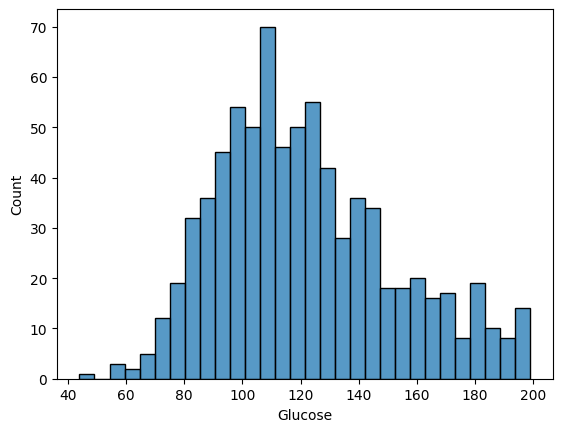

In [104]:
sns.histplot(df["Glucose"], bins=30)

<Axes: xlabel='Glucose', ylabel='Count'>

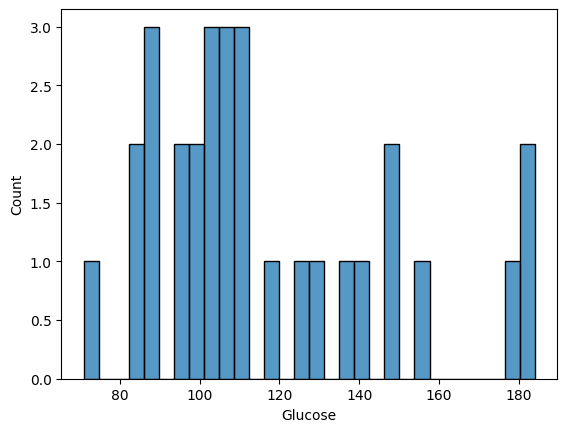

In [105]:
sns.histplot(sample, bins=30)

In [106]:
sample_data = []

for i in range(1000):
    sample = df["Glucose"].sample(n=30, replace=True)
    sample_data.append(sample.mean())

sample_data = np.array(sample_data)
mean_of_sample_data = sample_data.mean()

print(f"Population mean {population_mean:.2f}")
print(f"Sample mean {mean_of_sample_data:.2f}")

Population mean 121.66
Sample mean 121.69


<Axes: ylabel='Count'>

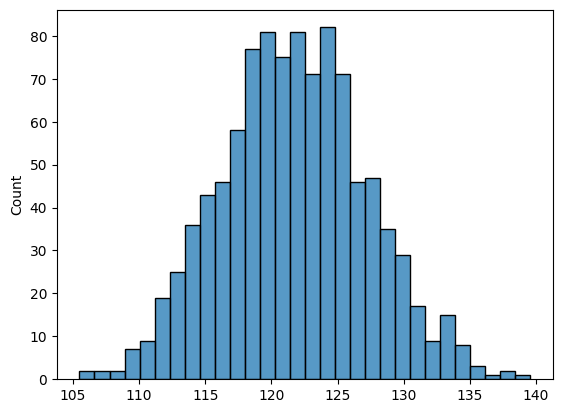

In [107]:
sns.histplot(sample_data, bins=30)

In [108]:
population_std = df["Glucose"].std()

sample_size = 50

SE = population_std / np.sqrt(sample_size)

print(f"Standard Error is {SE:.2f}")

Standard Error is 4.30


In [109]:
population_std = df["Glucose"].std()

sample_size = len(df)

SE = population_std / np.sqrt(sample_size)

print(f"Standard Error is {SE:.2f}")

Standard Error is 1.10


In [110]:
x = df["Glucose"]
y = df["BMI"]
cov_matrix = x.cov(y)
print(cov_matrix)



48.35120599739243


In [111]:
df.nunique()

Pregnancies                  16
Glucose                     135
BloodPressure                46
SkinThickness                50
Insulin                     185
BMI                         247
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [112]:
diabetic = df[df["Outcome"] == 1]["Glucose"]
non_diabetic = df[df["Outcome"] == 0]["Glucose"]

t_statistic, p_value = stats.ttest_ind(diabetic, non_diabetic)
print(t_statistic, p_value)

alpha = .05

if p_value < alpha:
    print("Reject the H0")
else:
    print("Fail to reject H0")

15.673795182294105 3.128719041842255e-48
Reject the H0


In [113]:
#CI = mean +/-Z*SE

std = df["Glucose"].std()
mean = df["Glucose"].mean()
n = len(df)

SE = std/np.sqrt(n)

CI95_lower = mean - (1.96 * SE)
CI95_upper = mean + (1.96 * SE)

print(CI95_lower, CI95_upper)

119.50348981712783 123.80901018287217


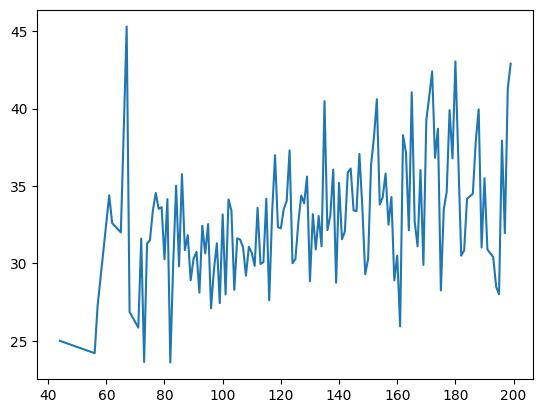

In [114]:
x = df.groupby(df["Glucose"])["BMI"].mean()

plt.plot(x.index, x.values)

<Axes: xlabel='Outcome', ylabel='count'>

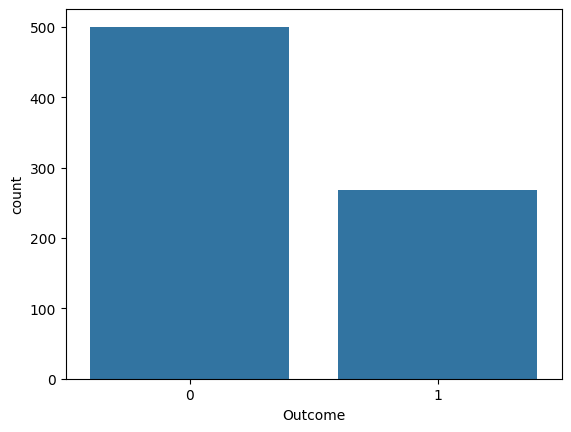

In [115]:
sns.countplot(x= df["Outcome"])

<Axes: xlabel='Glucose', ylabel='Count'>

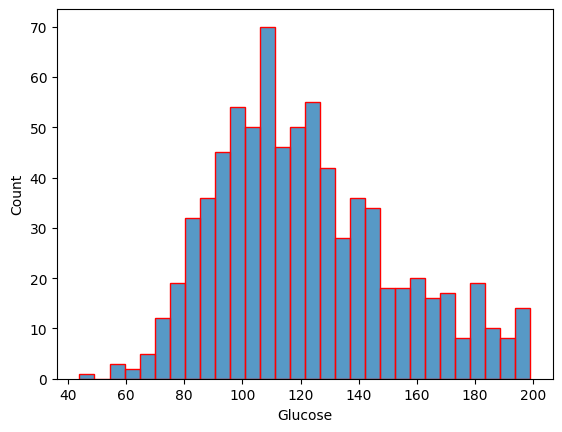

In [116]:
sns.histplot(df["Glucose"], bins=30, edgecolor = "r")

([<matplotlib.patches.Wedge at 0x1bf9701c550>,
 [Text(-0.5025944173008549, 0.9784676038060812, 'Diabetic'),
  Text(0.502594502841211, -0.9784675598678764, 'Non-diabetic')],
 [Text(-0.2741424094368299, 0.5337096020760442, '65.1%'),
  Text(0.27414245609520593, -0.5337095781097507, '34.9%')])

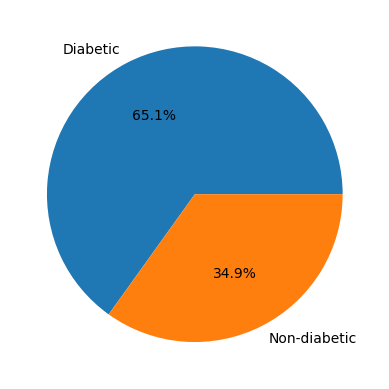

In [117]:
plt.pie(df["Outcome"].value_counts(),
        labels=["Diabetic", "Non-diabetic"],
        autopct="%1.1f%%")

<Axes: xlabel='Glucose'>

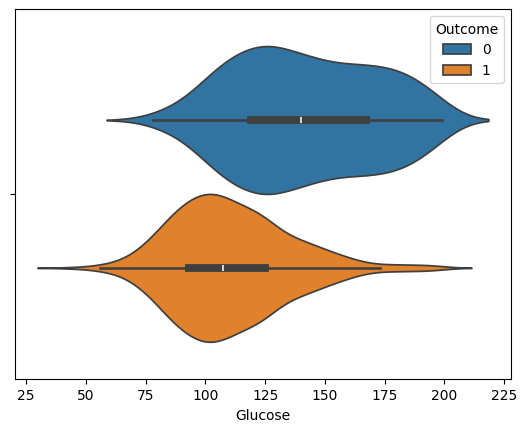

In [118]:
sns.violinplot(x=df["Glucose"], hue=df["Outcome"])

<Axes: ylabel='BMI'>

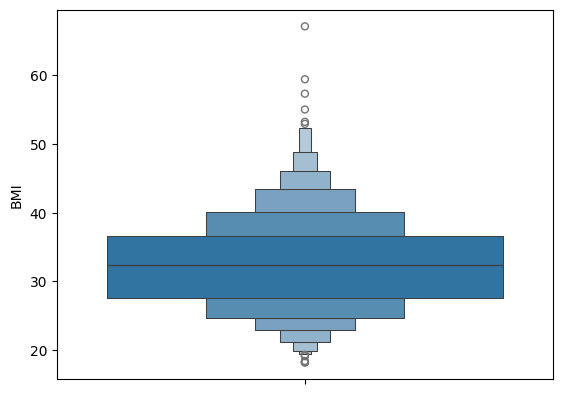

In [119]:
sns.boxenplot(y=df["BMI"])

<Axes: xlabel='Glucose', ylabel='BMI'>

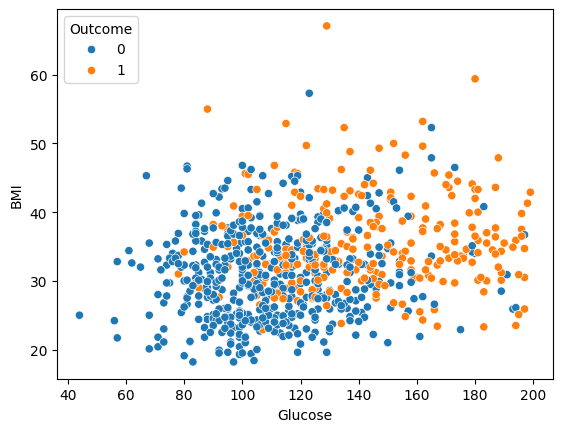

In [120]:
sns.scatterplot(x=df["Glucose"], y=df["BMI"], hue=df["Outcome"])

<Axes: >

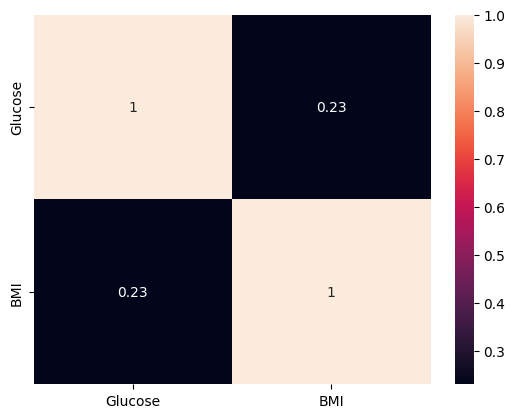

In [121]:
sns.heatmap(df[["Glucose", "BMI"]].corr(), annot=True)

<Axes: >

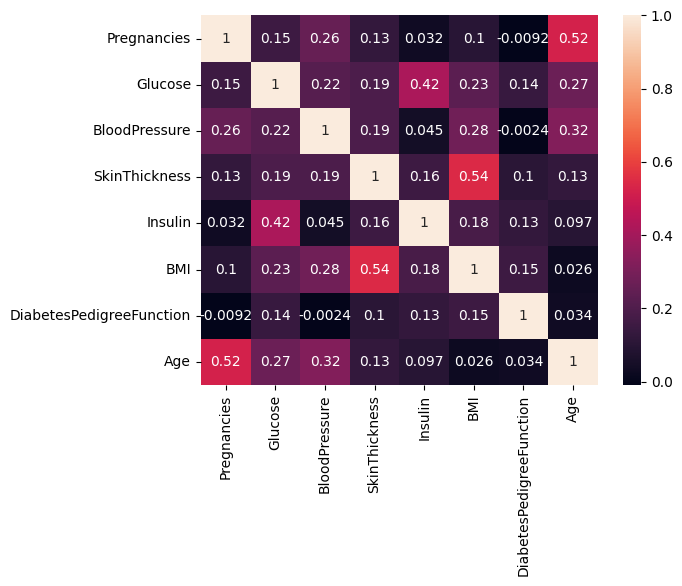

In [122]:
num_col = df.select_dtypes(np.number)
#num_col = df.select_dtypes(include=df[["BMI", "Glucose"]])

sns.heatmap(num_col.corr(), annot=True)